In [1]:
# Step 1: Install necessary libraries
!pip install h5py

# Step 2: Import required libraries
import h5py
import requests
from io import BytesIO
import numpy as np
import pandas as pd

In [2]:
import requests
from io import BytesIO

# Step 3: Download the file
url = 'https://github.com/NREL/ReEDS-2.0/raw/refs/heads/main/inputs/load/EER_Baseline_AEO2023_load_hourly.h5'
response = requests.get(url, stream=True) # Use stream=True for large files
file_content = BytesIO()
for chunk in response.iter_content(chunk_size=8192): # Iterate over content in chunks
    file_content.write(chunk)
print(file_content)

In [3]:
#  Download the file
url_bl = 'https://raw.githubusercontent.com/Raziye-Aghapour/Energy_2024/main/Baselineload.csv'
response = requests.get(url_bl)
Base_load_csv = BytesIO(response.content)
df_Base_load_csv = pd.read_csv(Base_load_csv)
# df_Base_load_csv

In [4]:
# Convert the unique values to a DataFrame and reset the index
unique_values = df_Base_load_csv[df_Base_load_csv.columns[0]].unique()
ReEDs_BA_sorted = pd.DataFrame(unique_values, columns=[df_Base_load_csv.columns[0]])
ReEDs_BA_sorted.reset_index(drop=True, inplace=True)

# Display the resulting DataFrame
print(ReEDs_BA_sorted)

        r
0      p1
1     p10
2    p100
3    p101
4    p102
..    ...
129   p95
130   p96
131   p97
132   p98
133   p99

[134 rows x 1 columns]


In [5]:
# Download the file
url_bl_ERCOT = 'https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/hierarchy.csv#/'
response = requests.get(url_bl_ERCOT)
ERCOT_BAs = BytesIO(response.content)
df_ERCOT_BAs = pd.read_csv(ERCOT_BAs)

In [6]:
# Assuming df_ERCOR_BAs is your DataFrame

# Step 1: Filter the DataFrame for rows where the second column ("nercr") is "ERCOT"
filtered_df = df_ERCOT_BAs[df_ERCOT_BAs['nercr'] == 'ERCOT']

# Step 2: Keep only the first ("ba") and second ("nercr") columns
filtered_df = filtered_df[['ba', 'nercr']]
filtered_BAs_ERCOT = filtered_df.reset_index(drop=True)

# Display the resulting filtered DataFrame
print(filtered_BAs_ERCOT)

    ba  nercr
0  p60  ERCOT
1  p61  ERCOT
2  p62  ERCOT
3  p63  ERCOT
4  p64  ERCOT
5  p65  ERCOT
6  p67  ERCOT


In [7]:
# Step 1: Filter df1 based on the 'ba' column in df2
filtered_df = ReEDs_BA_sorted[ReEDs_BA_sorted['r'].isin(filtered_BAs_ERCOT['ba'])]

# Step 2: Create a list of tuples with index and 'r' values
ERCOT_BAs_load_index = list(filtered_df.itertuples(index=True, name=None))

# Display the result
print(ERCOT_BAs_load_index)

[(91, 'p60'), (92, 'p61'), (93, 'p62'), (94, 'p63'), (95, 'p64'), (96, 'p65'), (98, 'p67')]


In [8]:
import h5py
import numpy as np # Ensure numpy is imported

# Columns to sum (as specified)
# The ERCOT_BAs_list contains the 'p' codes for the ERCOT balancing areas.
# The index_list should be actual column indices in the HDF5 data for these 'p' codes.
ERCOT_BAs_list = [item[1] for item in ERCOT_BAs_load_index] # Second element ('r' value)

print(ERCOT_BAs_list)


# Initialize a dictionary to store the results for each region
Increase_2010_base_ba = {ba: [] for ba in ERCOT_BAs_list} # Use BA names as keys for clarity
results_annual_inrease = []

# Open the HDF5 file
with h5py.File(file_content, 'r') as f:
    print("Keys available in HDF5 file:", list(f.keys()))

    # Get the data, region names, and dimension labels
    full_data = f['data'][:]
    region_labels = [col.decode('utf-8') for col in f['columns']]
    dimension_names_decoded = [name.decode('utf-8') for name in f['index_names']]

    print("Shape of 'data' dataset:", full_data.shape)
    print("HDF5 region labels (from 'columns'):", region_labels)
    print("HDF5 index_names:", dimension_names_decoded)



    # Correcting the decode error: index_0 contains integers (years), index_1 contains byte strings (datetimes)
    year_labels_h5 = f['index_0'][:]
    datetime_labels_h5 = [x.decode('utf-8') for x in f['index_1'][:]]

    print("Content of index_0 (years):", np.unique(year_labels_h5))
    print("Content of index_1 (datetimes, sample):", datetime_labels_h5[:5]) # Print a sample for brevity

    # Now, dynamically create the index_list (column indices) based on ERCOT_BAs_list and region_labels
    index_list_for_data = [region_labels.index(ba_name) for ba_name in ERCOT_BAs_list]
    print("Column indices for ERCOT BAs in full_data:", index_list_for_data)

    # Check that each year has the same number of rows
    years = np.unique(year_labels_h5)
    rows_per_year = {y: int(np.sum(year_labels_h5 == y)) for y in years}
    print("Rows per year: min=", min(rows_per_year.values()), "max=", max(rows_per_year.values()))
    bad = [y for y,c in rows_per_year.items() if c != rows_per_year[years[0]]]
    print("Years with different row counts:", bad)

    # Check if any year has lots of zeros/NaNs in ERCOT columns (especially 2021)
    ercot_cols = index_list_for_data
    for y in [2020, 2021, 2022]:
      idx = np.where(year_labels_h5 == y)[0]
      block = full_data[idx][:, ercot_cols]
      print(f"\nYear {y}: shape={block.shape}, nan={np.isnan(block).sum()}, zero={(block==0).sum()}, "
          f"min={np.nanmin(block):.3f}, max={np.nanmax(block):.3f}")

    # Find the row indices for the base year (2010)
    base_year = 2010 # Use integer for year comparison
    base_year_rows_indices = np.where(year_labels_h5 == base_year)[0]

    if len(base_year_rows_indices) == 0:
        raise KeyError(f"Year '{base_year}' not found in HDF5 data. Please check available years.")

    # Extract data for 2010 for all regions (rows corresponding to 2010, all columns)
    base_2010_ReEDS_load = full_data[base_year_rows_indices, :]
    # Sum across the datetime dimension for each region to get total annual load for 2010
    column_sums_2010 = np.sum(base_2010_ReEDS_load, axis=0)
    # Sum the specified ERCOT regions for 2010
    sum_of_specified_previous_year = np.sum(column_sums_2010[index_list_for_data])

    # Loop through the years from 2011 to 2050
    for year in range(2011, 2051):
        current_year_rows_indices = np.where(year_labels_h5 == year)[0]

        if len(current_year_rows_indices) > 0:
            # Access the data for the current year
            dataset_year = full_data[current_year_rows_indices, :]
            column_sums_year = np.sum(dataset_year, axis=0)

            # Sum the specified columns for the current year
            sum_of_specified_balancing_areas_year = np.sum(column_sums_year[index_list_for_data])

            # Calculate the percentage increase compared to the previous year
            increase_percentage = ((sum_of_specified_balancing_areas_year - sum_of_specified_previous_year) / sum_of_specified_previous_year) * 100

            # Append the year and percentage increase to the results list
            results_annual_inrease.append([year, increase_percentage])

            # Update the previous year's sum for the next iteration
            sum_of_specified_previous_year = sum_of_specified_balancing_areas_year

            # For each specified region (column), calculate the percentage increase
            for i, col_index_in_data in enumerate(index_list_for_data):
                ba_name = ERCOT_BAs_list[i]
                # Calculate the percentage increase for each column (region)
                increase_percentage_ba = ((column_sums_year[col_index_in_data] - column_sums_2010[col_index_in_data]) / column_sums_2010[col_index_in_data]) * 100

                # Append the year and percentage increase for each column to the corresponding list in the dictionary
                Increase_2010_base_ba[ba_name].append([year, increase_percentage_ba])
        else:
            print(f"Warning: Year '{year}' not found in HDF5 data. Skipping.")

print("Results annual increase:", results_annual_inrease)
print("Increase 2010 base ba:", Increase_2010_base_ba)

['p60', 'p61', 'p62', 'p63', 'p64', 'p65', 'p67']
Keys available in HDF5 file: ['columns', 'data', 'index_0', 'index_1', 'index_names']
Shape of 'data' dataset: (5387400, 134)
HDF5 region labels (from 'columns'): ['p1', 'p10', 'p100', 'p101', 'p102', 'p103', 'p104', 'p105', 'p106', 'p107', 'p108', 'p109', 'p11', 'p110', 'p111', 'p112', 'p113', 'p114', 'p115', 'p116', 'p117', 'p118', 'p119', 'p12', 'p120', 'p121', 'p122', 'p123', 'p124', 'p125', 'p126', 'p127', 'p128', 'p129', 'p13', 'p130', 'p131', 'p132', 'p133', 'p134', 'p14', 'p15', 'p16', 'p17', 'p18', 'p19', 'p2', 'p20', 'p21', 'p22', 'p23', 'p24', 'p25', 'p26', 'p27', 'p28', 'p29', 'p3', 'p30', 'p31', 'p32', 'p33', 'p34', 'p35', 'p36', 'p37', 'p38', 'p39', 'p4', 'p40', 'p41', 'p42', 'p43', 'p44', 'p45', 'p46', 'p47', 'p48', 'p49', 'p5', 'p50', 'p51', 'p52', 'p53', 'p54', 'p55', 'p56', 'p57', 'p58', 'p59', 'p6', 'p60', 'p61', 'p62', 'p63', 'p64', 'p65', 'p66', 'p67', 'p68', 'p69', 'p7', 'p70', 'p71', 'p72', 'p73', 'p74', 'p75', 'p


ERCOT total YoY growth (%) — 2020 to 2030
 year  ercot_yoy_pct
 2020         -0.434
 2021        -27.420
 2022          8.935
 2023          3.830
 2024         -1.268
 2025          2.306
 2026          2.565
 2027          2.501
 2028          2.440
 2029          2.382
 2030          2.327


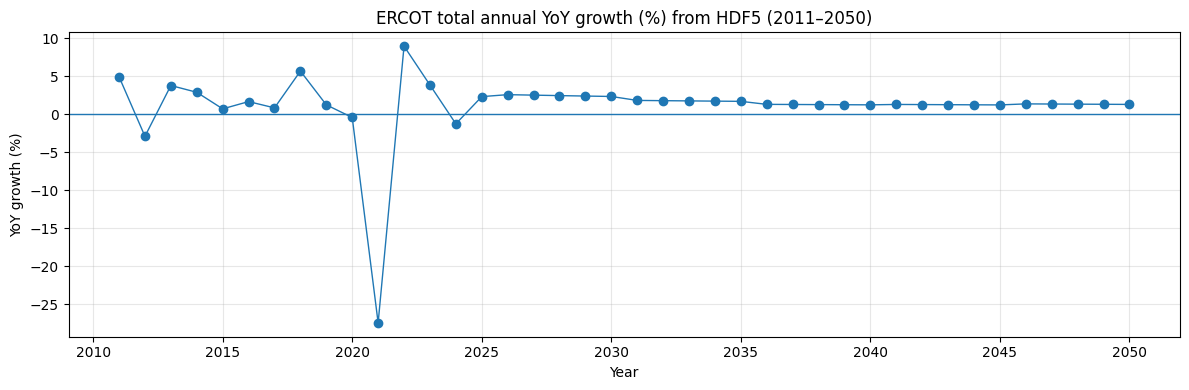

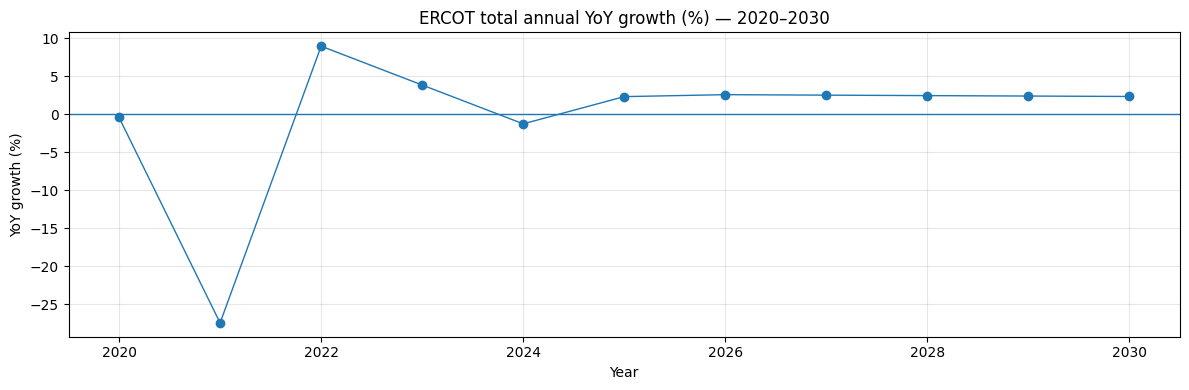


BA growth vs 2010 (%): wide table head
ba    p60  p61  p62  p63  p64  p65  p67
year                                   
2011 4.92 4.92 4.92 4.92 4.92 4.92 4.92
2012 1.87 1.87 1.87 1.87 1.87 1.87 1.87
2013 5.71 5.71 5.71 5.71 5.71 5.71 5.71
2014 8.75 8.75 8.75 8.75 8.75 8.75 8.75
2015 9.51 9.51 9.51 9.51 9.51 9.51 9.51


Text(0.5, 0, 'Year')

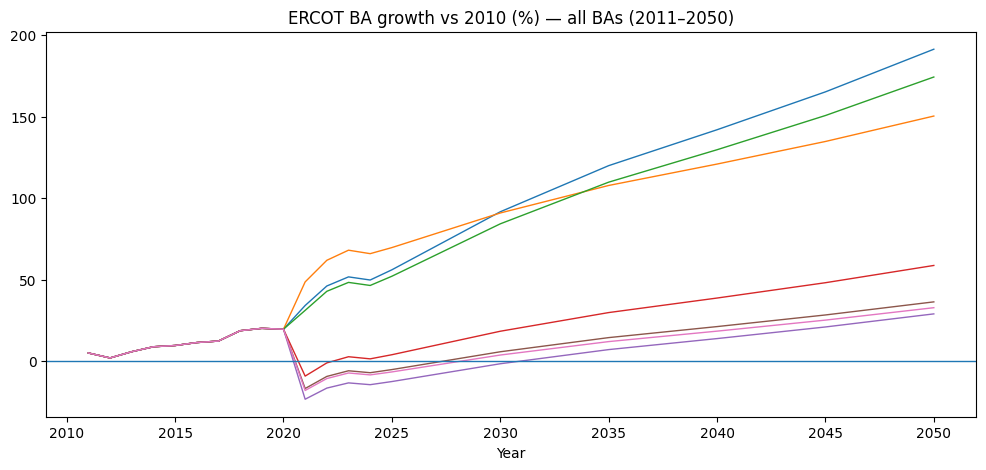

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1) ERCOT total YoY growth (%)
# ----------------------------
df_yoy = pd.DataFrame(results_annual_inrease, columns=["year", "ercot_yoy_pct"])
df_yoy["year"] = df_yoy["year"].astype(int)
df_yoy["ercot_yoy_pct"] = df_yoy["ercot_yoy_pct"].astype(float)

# Table for 2020–2030
df_yoy_2020_2030 = df_yoy[(df_yoy["year"] >= 2020) & (df_yoy["year"] <= 2030)].copy()
print("\nERCOT total YoY growth (%) — 2020 to 2030")
print(df_yoy_2020_2030.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

# Plot full horizon YoY
plt.figure(figsize=(12, 4))
plt.plot(df_yoy["year"], df_yoy["ercot_yoy_pct"], marker="o", linewidth=1)
plt.axhline(0, linewidth=1)
plt.title("ERCOT total annual YoY growth (%) from HDF5 (2011–2050)")
plt.xlabel("Year")
plt.ylabel("YoY growth (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ercot_yoy_growth_2011_2050.png", dpi=200)
plt.show()

# Plot zoomed 2020–2030
plt.figure(figsize=(12, 4))
plt.plot(df_yoy_2020_2030["year"], df_yoy_2020_2030["ercot_yoy_pct"], marker="o", linewidth=1)
plt.axhline(0, linewidth=1)
plt.title("ERCOT total annual YoY growth (%) — 2020–2030")
plt.xlabel("Year")
plt.ylabel("YoY growth (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ercot_yoy_growth_2020_2030.png", dpi=200)
plt.show()

# Save the YoY table
df_yoy.to_csv("ercot_yoy_growth_2011_2050.csv", index=False)
df_yoy_2020_2030.to_csv("ercot_yoy_growth_2020_2030.csv", index=False)


# -------------------------------------------
# 2) BA growth vs 2010 (%) — tidy + wide forms
# -------------------------------------------
rows = []
for ba, series in Increase_2010_base_ba.items():
    for yr, pct in series:
        rows.append({"ba": ba, "year": int(yr), "growth_vs_2010_pct": float(pct)})

df_ba_long = pd.DataFrame(rows).sort_values(["ba", "year"])
df_ba_wide = df_ba_long.pivot(index="year", columns="ba", values="growth_vs_2010_pct").sort_index()

print("\nBA growth vs 2010 (%): wide table head")
print(df_ba_wide.head().to_string(float_format=lambda x: f"{x:,.2f}"))

df_ba_long.to_csv("ercot_ba_growth_vs_2010_long.csv", index=False)
df_ba_wide.to_csv("ercot_ba_growth_vs_2010_wide.csv", index=True)


# -----------------------------------
# 3) Plot all BA growth vs 2010 (%)
# -----------------------------------
plt.figure(figsize=(12, 5))
for ba in df_ba_wide.columns:
    plt.plot(df_ba_wide.index, df_ba_wide[ba], linewidth=1, label=ba)

plt.axhline(0, linewidth=1)
plt.title("ERCOT BA growth vs 2010 (%) — all BAs (2011–2050)")
plt.xlabel("Year")

Detected 131400 rows/year = 15 realizations × 8760 hours.


/tmp/ipython-input-2763147658.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dt = pd.date_range(start=f"{y}-01-01 00:00:00", periods=HOURS_PER_YEAR, freq="H")


Saved hourly ERCOT series to: ercot_hourly_2020_2050_mean_hourly.csv


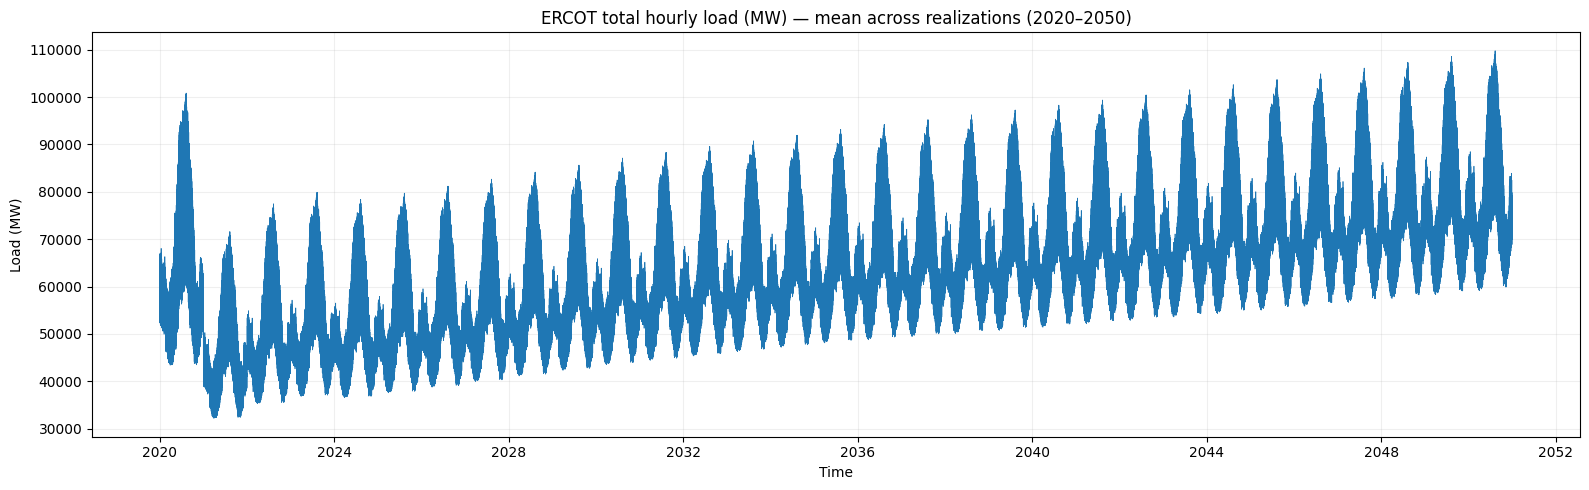

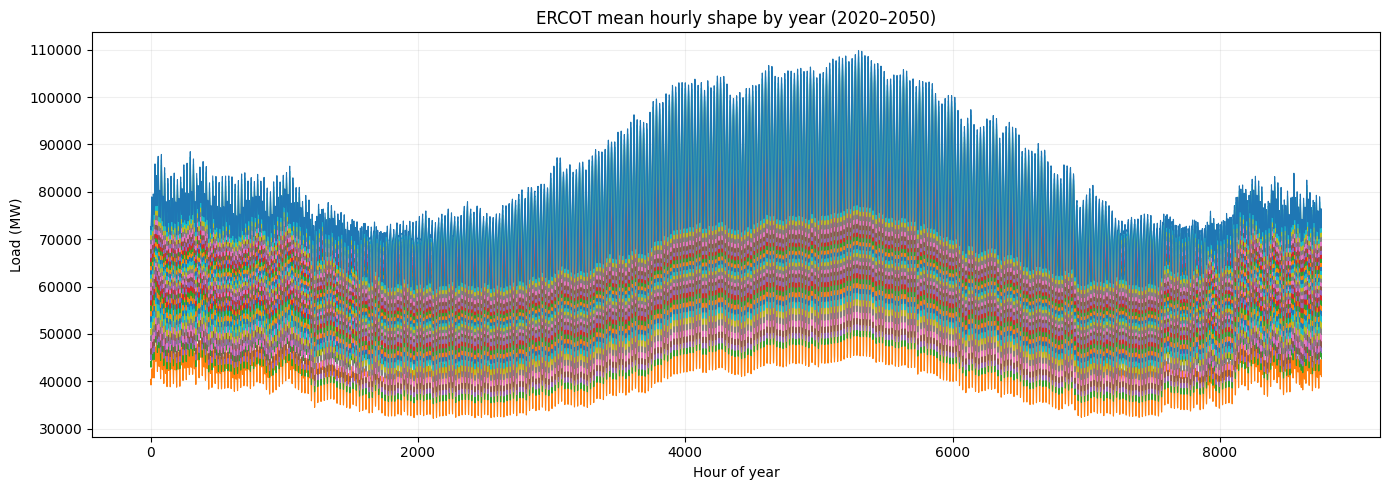

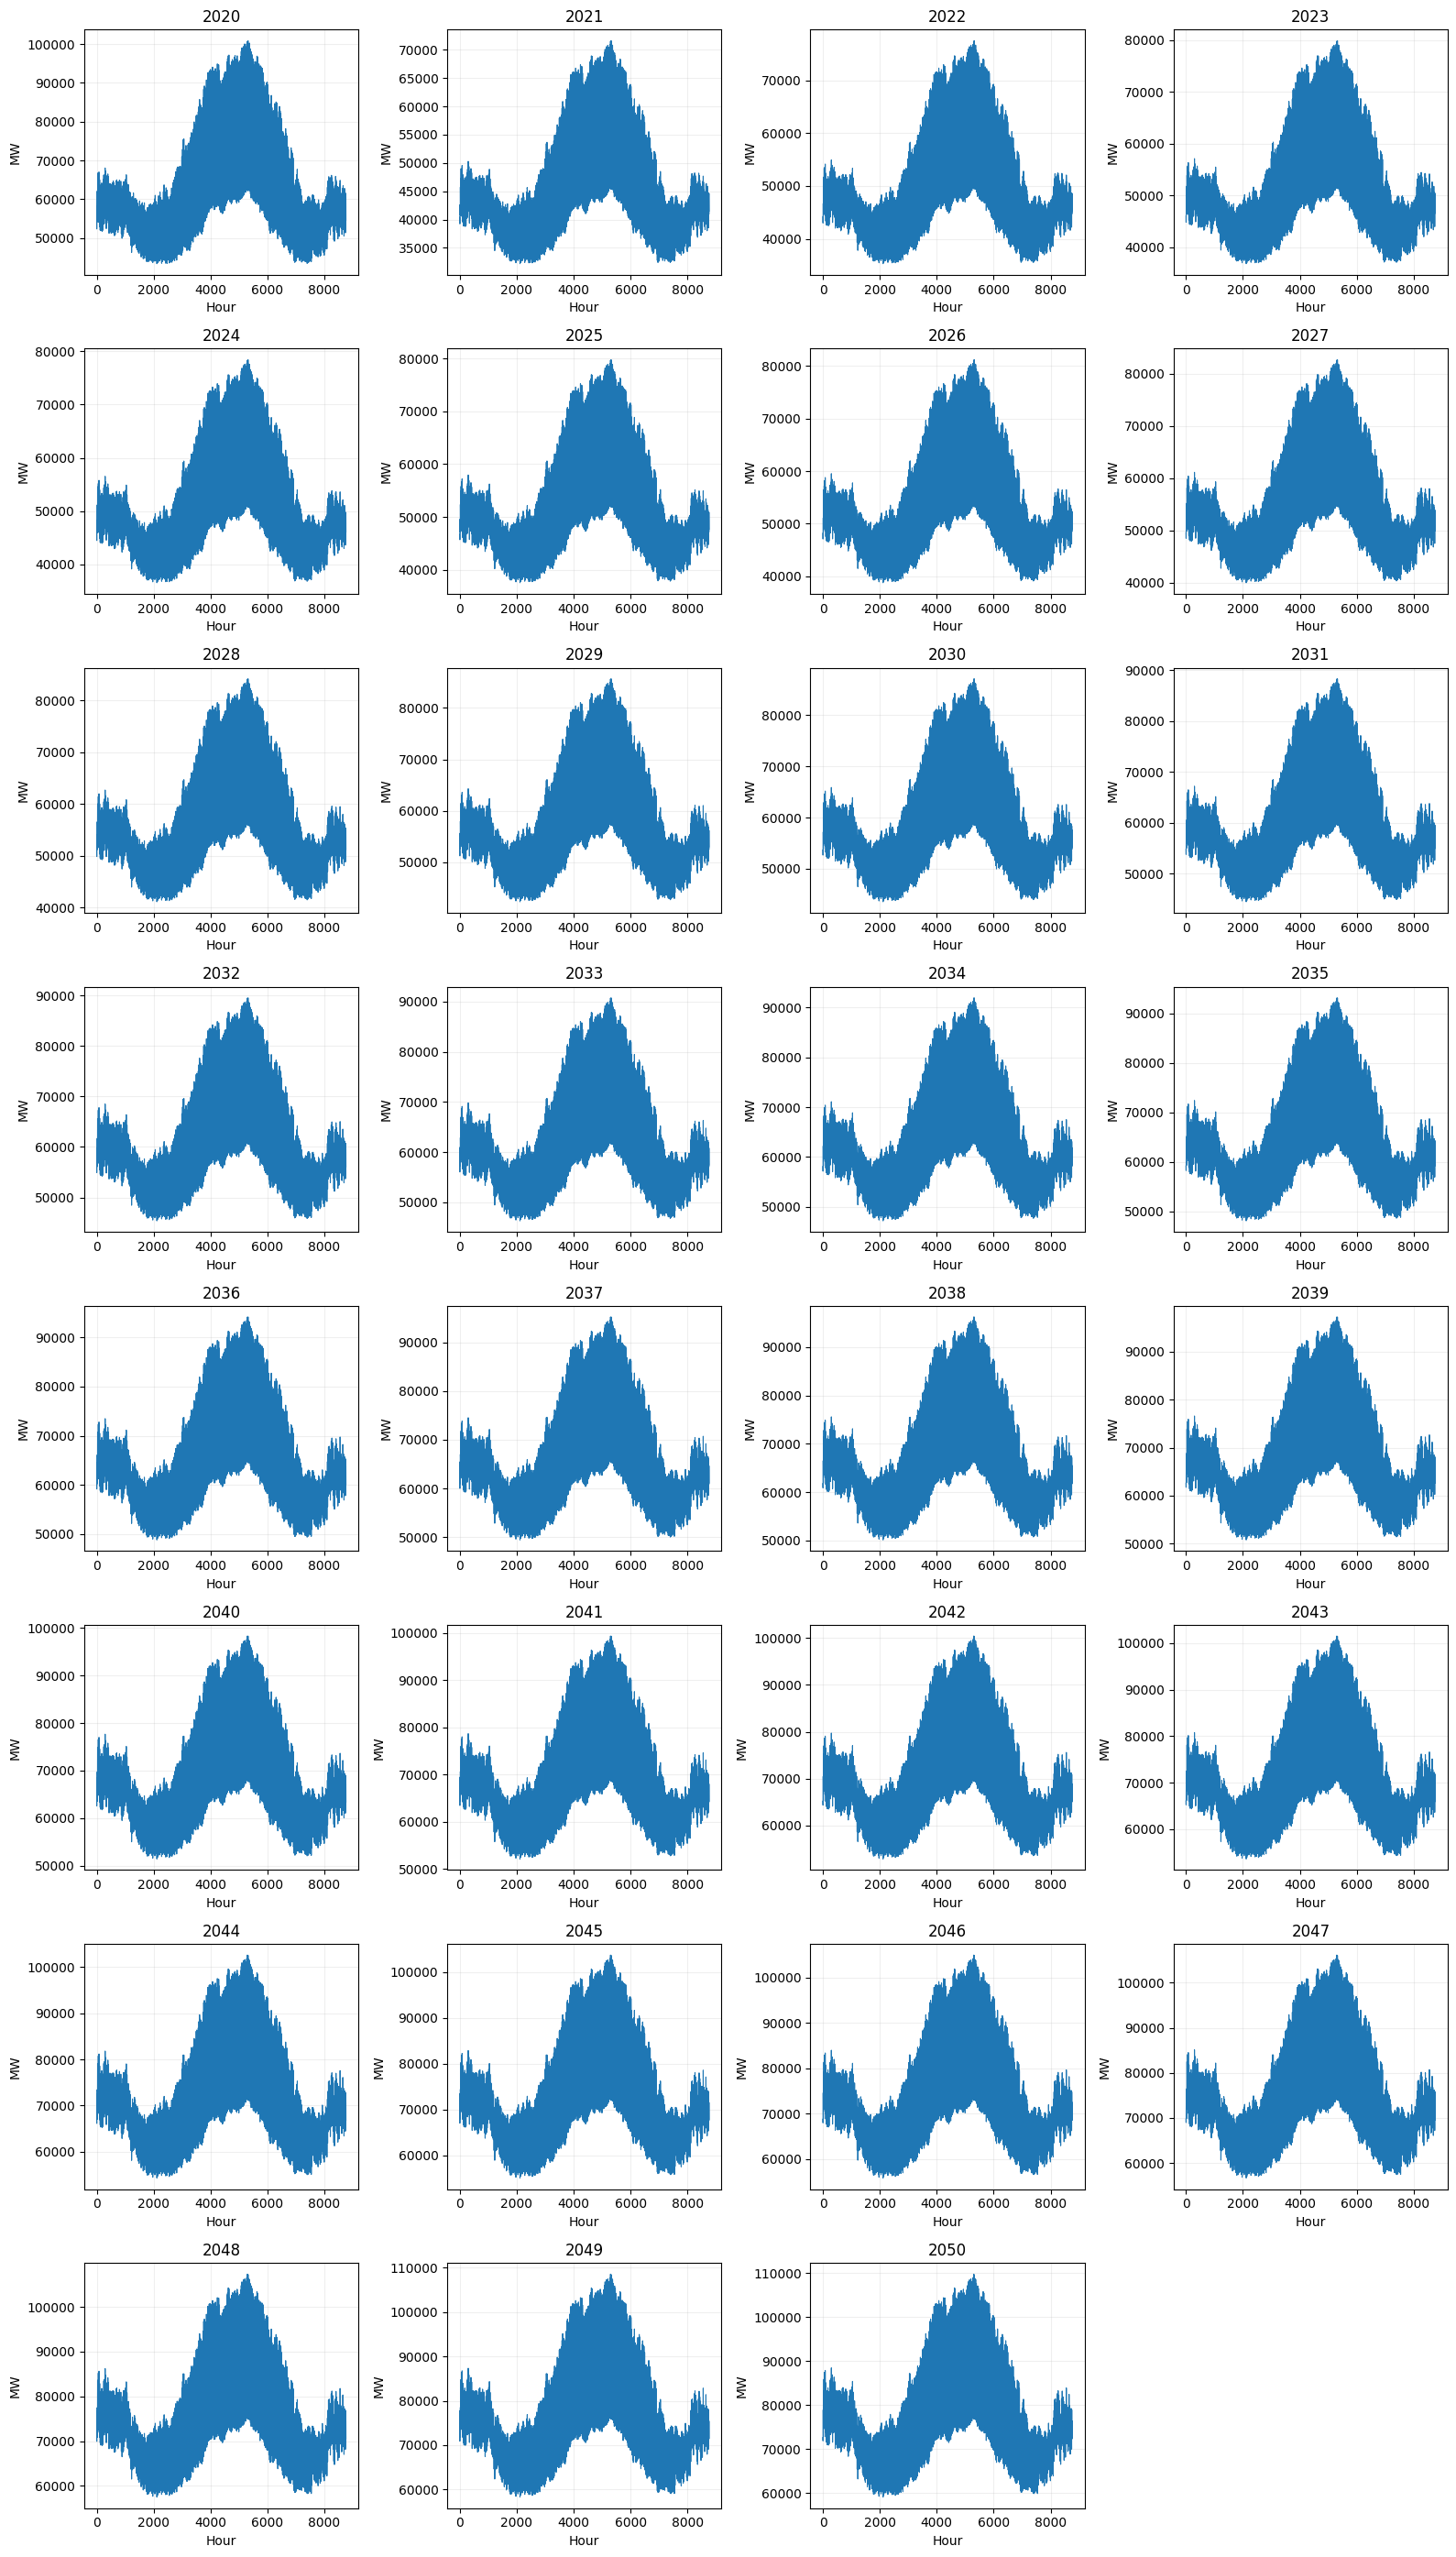

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Settings
# -----------------------
YEAR_START, YEAR_END = 2020, 2050
HOURS_PER_YEAR = 8760

ercot_cols = index_list_for_data  # your ERCOT BA column indices in HDF5 'data'

# Confirm rows per year and infer number of realizations
rows_per_year = int(np.sum(year_labels_h5 == YEAR_START))
if rows_per_year % HOURS_PER_YEAR != 0:
    raise ValueError(f"Rows per year ({rows_per_year}) is not divisible by 8760. Can't reshape reliably.")

N_REALIZATIONS = rows_per_year // HOURS_PER_YEAR
print(f"Detected {rows_per_year} rows/year = {N_REALIZATIONS} realizations × {HOURS_PER_YEAR} hours.")

# -----------------------
# Build hourly series: mean across realizations for each year
# -----------------------
years = list(range(YEAR_START, YEAR_END + 1))

all_dt = []
all_load = []

for y in years:
    idx = np.where(year_labels_h5 == y)[0]
    if len(idx) == 0:
        print(f"Warning: year {y} not found, skipping.")
        continue

    block = full_data[idx][:, ercot_cols]      # (rows_per_year, 7)
    ercot_hourly = block.sum(axis=1)           # (rows_per_year,)

    # reshape to (realizations, 8760)
    ercot_hr = ercot_hourly.reshape(N_REALIZATIONS, HOURS_PER_YEAR)

    # mean hourly across realizations -> one 8760 series
    ercot_mean = ercot_hr.mean(axis=0)         # (8760,)

    # build a datetime index for plotting (year is "model year")
    dt = pd.date_range(start=f"{y}-01-01 00:00:00", periods=HOURS_PER_YEAR, freq="H")

    all_dt.append(dt)
    all_load.append(ercot_mean)

# Concatenate into one long series
dt_all = all_dt[0].append(all_dt[1:]) if len(all_dt) > 1 else all_dt[0]
load_all = np.concatenate(all_load)

ercot_series = pd.Series(load_all, index=dt_all, name="ERCOT_hourly_MW_mean_across_realizations")

# Save to CSV
ercot_series.to_csv("ercot_hourly_2020_2050_mean_hourly.csv", header=True)
print("Saved hourly ERCOT series to: ercot_hourly_2020_2050_mean_hourly.csv")

# -----------------------
# Plot 1: Continuous hourly series (2020–2050)
# -----------------------
plt.figure(figsize=(16, 5))
plt.plot(ercot_series.index, ercot_series.values, linewidth=0.5)
plt.title("ERCOT total hourly load (MW) — mean across realizations (2020–2050)")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("ercot_hourly_2020_2050_continuous.png", dpi=200)
plt.show()

# -----------------------
# Plot 2 (optional): One line per year (mean hourly shape)
# This compares shapes across years, not absolute time
# -----------------------
plt.figure(figsize=(14, 5))
for i, y in enumerate(years):
    # slice the series for that year
    yr = ercot_series[str(y)]
    # x-axis = hour of year (0..8759)
    plt.plot(np.arange(len(yr)), yr.values, linewidth=0.8, label=str(y))

plt.title("ERCOT mean hourly shape by year (2020–2050)")
plt.xlabel("Hour of year")
plt.ylabel("Load (MW)")
plt.grid(True, alpha=0.2)

# legend will be huge; comment out if you don't want it
# plt.legend(ncol=4, fontsize=7, frameon=False)

plt.tight_layout()
plt.savefig("ercot_hourly_shape_by_year_2020_2050.png", dpi=200)
plt.show()

# -----------------------
# Plot 3 (optional): Small multiples (per-year panels)
# -----------------------
n = len(years)
ncols = 4
nrows = int(np.ceil(n / ncols))

plt.figure(figsize=(16, 3.5 * nrows))
for j, y in enumerate(years, start=1):
    ax = plt.subplot(nrows, ncols, j)
    yr = ercot_series[str(y)]
    ax.plot(np.arange(len(yr)), yr.values, linewidth=0.8)
    ax.set_title(str(y))
    ax.set_xlabel("Hour")
    ax.set_ylabel("MW")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("ercot_hourly_small_multiples_2020_2050.png", dpi=200)
plt.show()


ERCOT BAs: ['p60', 'p61', 'p62', 'p63', 'p64', 'p65', 'p67']
Keys available in HDF5 file: ['columns', 'data', 'index_0', 'index_1', 'index_names']
Shape of 'data' dataset: (5387400, 134)
HDF5 index_names: ['year', 'datetime']
Years available: [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2024 2025 2026 2027 2028 2029 2030 2031 2032 2033 2034 2035 2036 2037
 2038 2039 2040 2041 2042 2043 2044 2045 2046 2047 2048 2049 2050]
Datetime sample: ['2007-01-01T00:00:00-06:00', '2007-01-01T01:00:00-06:00', '2007-01-01T02:00:00-06:00']
Column indices for ERCOT BAs in full_data: [91, 92, 93, 94, 95, 96, 98]
Rows per year: min= 131400 max= 131400
Years with different row counts: []
Detected 15 realizations per model year (rows/year=131400).

Year 2020: shape=(131400, 7), nan=0, zero=0, min=257.007, max=45860.802

Year 2021: shape=(131400, 7), nan=0, zero=0, min=289.000, max=31181.000

Year 2022: shape=(131400, 7), nan=0, zero=0, min=319.000, max=33693.000

2010 ERCOT total

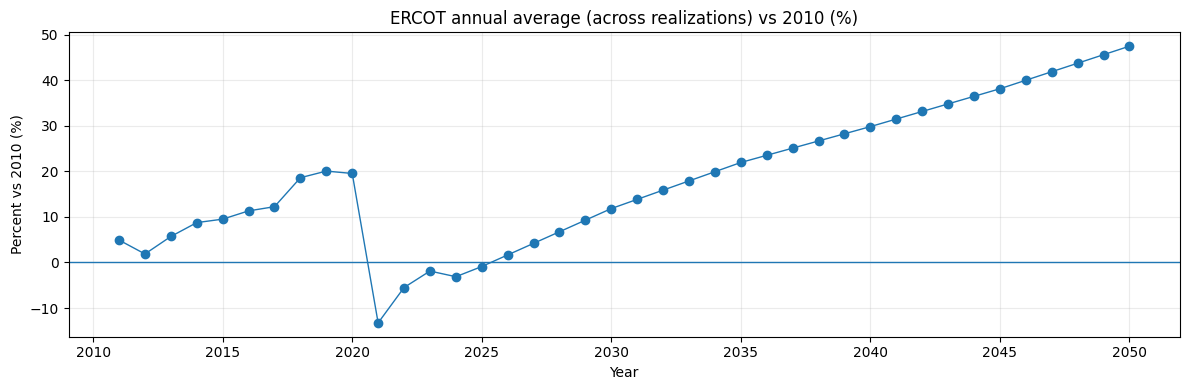

In [11]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ERCOT_BAs_list from your earlier ERCOT_BAs_load_index
ERCOT_BAs_list = [item[1] for item in ERCOT_BAs_load_index]
print("ERCOT BAs:", ERCOT_BAs_list)

Increase_2010_base_ba = {ba: [] for ba in ERCOT_BAs_list}
results_annual_inrease = []

# NEW: ERCOT annual avg vs 2010 (percent)
ercot_avg_vs_2010 = []   # list of [year, pct_vs_2010]
ercot_avg_annual = []    # list of [year, avg_annual_energy]

with h5py.File(file_content, 'r') as f:
    print("Keys available in HDF5 file:", list(f.keys()))

    # Load metadata
    full_data = f['data'][:]  # big array
    region_labels = [col.decode('utf-8') for col in f['columns']]
    dimension_names_decoded = [name.decode('utf-8') for name in f['index_names']]

    print("Shape of 'data' dataset:", full_data.shape)
    print("HDF5 index_names:", dimension_names_decoded)

    year_labels_h5 = f['index_0'][:]  # ints
    datetime_labels_h5 = [x.decode('utf-8') for x in f['index_1'][:]]  # bytes -> str

    print("Years available:", np.unique(year_labels_h5))
    print("Datetime sample:", datetime_labels_h5[:3])

    # ERCOT column indices
    missing = [ba for ba in ERCOT_BAs_list if ba not in region_labels]
    if missing:
        raise ValueError(f"These ERCOT BAs were not found in HDF5 columns: {missing}")

    index_list_for_data = [region_labels.index(ba) for ba in ERCOT_BAs_list]
    print("Column indices for ERCOT BAs in full_data:", index_list_for_data)

    # Rows per year -> infer realizations
    years = np.unique(year_labels_h5)
    rows_per_year = {y: int(np.sum(year_labels_h5 == y)) for y in years}
    print("Rows per year: min=", min(rows_per_year.values()), "max=", max(rows_per_year.values()))
    bad = [y for y, c in rows_per_year.items() if c != rows_per_year[years[0]]]
    print("Years with different row counts:", bad)

    HOURS_PER_YEAR = 8760
    rows0 = rows_per_year[int(years[0])]
    if rows0 % HOURS_PER_YEAR != 0:
        raise ValueError(f"Rows/year ({rows0}) not divisible by 8760; can't infer realizations cleanly.")
    N_REALIZATIONS = rows0 // HOURS_PER_YEAR
    print(f"Detected {N_REALIZATIONS} realizations per model year (rows/year={rows0}).")

    # Sanity check on ERCOT columns for a few years
    ercot_cols = index_list_for_data
    for y in [2020, 2021, 2022]:
        idx = np.where(year_labels_h5 == y)[0]
        block = full_data[idx][:, ercot_cols]
        print(f"\nYear {y}: shape={block.shape}, nan={np.isnan(block).sum()}, zero={(block==0).sum()}, "
              f"min={np.nanmin(block):.3f}, max={np.nanmax(block):.3f}")

    # ---- Base year (2010) annual totals ----
    base_year = 2010
    base_idx = np.where(year_labels_h5 == base_year)[0]
    if len(base_idx) == 0:
        raise KeyError(f"Year '{base_year}' not found in HDF5 data.")

    base_2010 = full_data[base_idx, :]                      # (rows_per_year, 134)
    colsum_2010 = np.sum(base_2010, axis=0)                 # annual totals summed over all realizations
    ercot_total_2010 = np.sum(colsum_2010[index_list_for_data])

    # NEW: average annual energy across realizations (2010)
    ercot_avg_2010 = ercot_total_2010 / N_REALIZATIONS

    # initialize for YoY
    sum_of_specified_previous_year = ercot_total_2010

    print("\n2010 ERCOT total annual (sum over all realizations):", ercot_total_2010)
    print("2010 ERCOT annual average (per realization):", ercot_avg_2010)

    # ---- Loop through years 2011–2050 ----
    for year in range(2011, 2051):
        idx = np.where(year_labels_h5 == year)[0]
        if len(idx) == 0:
            print(f"Warning: Year '{year}' not found. Skipping.")
            continue

        dataset_year = full_data[idx, :]
        colsum_year = np.sum(dataset_year, axis=0)

        # ERCOT annual total (sum over all realizations)
        ercot_total_year = np.sum(colsum_year[index_list_for_data])

        # 1) YoY growth of ERCOT total (same as you had)
        yoy_pct = ((ercot_total_year - sum_of_specified_previous_year) / sum_of_specified_previous_year) * 100
        results_annual_inrease.append([year, float(yoy_pct)])
        sum_of_specified_previous_year = ercot_total_year

        # 2) NEW: ERCOT annual AVERAGE across realizations
        ercot_avg_year = ercot_total_year / N_REALIZATIONS
        ercot_avg_annual.append([year, float(ercot_avg_year)])

        # 3) NEW: ERCOT annual average vs 2010 (%)
        pct_vs_2010 = ((ercot_avg_year - ercot_avg_2010) / ercot_avg_2010) * 100
        ercot_avg_vs_2010.append([year, float(pct_vs_2010)])

        # 4) BA growth vs 2010 (%), same as you had
        for i, col_index_in_data in enumerate(index_list_for_data):
            ba_name = ERCOT_BAs_list[i]
            denom = colsum_2010[col_index_in_data]
            if denom == 0:
                inc_ba = np.nan
            else:
                inc_ba = ((colsum_year[col_index_in_data] - denom) / denom) * 100
            Increase_2010_base_ba[ba_name].append([year, float(inc_ba)])

# -----------------------
# Convert to DataFrames
# -----------------------
df_yoy = pd.DataFrame(results_annual_inrease, columns=["year", "ercot_yoy_pct"])
df_vs2010 = pd.DataFrame(ercot_avg_vs_2010, columns=["year", "ercot_avg_vs_2010_pct"])
df_avg = pd.DataFrame(ercot_avg_annual, columns=["year", "ercot_avg_annual_energy"])

print("\nERCOT YoY growth (%):")
print(df_yoy.head().to_string(index=False))

print("\nERCOT annual average vs 2010 (%):")
print(df_vs2010.head().to_string(index=False))

# Save tables
df_yoy.to_csv("ercot_yoy_growth_2011_2050.csv", index=False)
df_vs2010.to_csv("ercot_avg_vs_2010_2011_2050.csv", index=False)
df_avg.to_csv("ercot_avg_annual_energy_2011_2050.csv", index=False)

# -----------------------
# Plot: ERCOT avg vs 2010 (%)
# -----------------------
plt.figure(figsize=(12, 4))
plt.plot(df_vs2010["year"], df_vs2010["ercot_avg_vs_2010_pct"], marker="o", linewidth=1)
plt.axhline(0, linewidth=1)
plt.title("ERCOT annual average (across realizations) vs 2010 (%)")
plt.xlabel("Year")
plt.ylabel("Percent vs 2010 (%)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("ercot_avg_vs_2010_2011_2050.png", dpi=200)
plt.show()
